# Notebook 05 — Earth-Moon: Orbital Mechanics Engine vs REBOUND

Compares our integrators against REBOUND's IAS15 and WHFast on the Sun-Earth-Moon system (3 bodies) over 1 year.

- **Our framework**: RK4, Leapfrog, RK45 (adaptive)
- **REBOUND**: IAS15 (15th-order adaptive), WHFast (symplectic Wisdom-Holman)

Metrics: wall-clock time, step count, energy drift, and drift over time.

In [6]:
import os
# Notebooks run from examples/ — step up to project root so system JSON paths resolve
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
import rebound
import orbit

G    = 6.674e-11
YEAR = 365.25 * 24 * 3600
N_TRACK = 200  # energy snapshots for REBOUND drift-over-time plot

SYSTEM = 'systems/earth_moon.json'

# Identical initial conditions for both frameworks
bodies_ic = [
    {'name': 'Sun',   'mass': 1.98847e30, 'pos': [0.0, 0.0, 0.0],           'vel': [0.0, 0.0, 0.0]},
    {'name': 'Earth', 'mass': 5.9722e24,  'pos': [1.496e11, 0.0, 0.0],      'vel': [0.0, 29780.0, 0.0]},
    {'name': 'Moon',  'mass': 7.342e22,   'pos': [1.49984400e11, 0.0, 0.0], 'vel': [0.0, 30802.0, 0.0]},
]

print(f'orbit {orbit.__version__}, rebound {rebound.__version__}')

orbit 2.0.0, rebound 5.0.0


## Run all integrators

In [8]:
results = {}

# --- Our framework ---
for label, integrator, kwargs in [
    ('Ours: RK4',        orbit.Integrator.RK4,      {'steps': 8760, 'dt': 3600.0}),
    ('Ours: Leapfrog',   orbit.Integrator.Leapfrog, {'steps': 8760, 'dt': 3600.0}),
    ('Ours: Yoshida4',   orbit.Integrator.Yoshida4, {'steps': 8760, 'dt': 3600.0}),
]:
    t0 = time.perf_counter()
    r = orbit.simulate(SYSTEM, integrator=integrator, **kwargs)
    elapsed = time.perf_counter() - t0
    E = r.energies_numpy()
    results[label] = {
        'time_ms': elapsed * 1000,
        'steps': kwargs['steps'],
        'drift': abs((E[-1] - E[0]) / E[0]),
        'E_rel': (E - E[0]) / abs(E[0]),
        't': np.linspace(0, YEAR / (365.25 * 24 * 3600), len(E)),
    }

for label, atol in [('Ours: RK45 (1e-9)', 1e-9), ('Ours: RK45 (1e-12)', 1e-12)]:
    t0 = time.perf_counter()
    r = orbit.simulate_adaptive(SYSTEM, duration_s=YEAR, dt_initial=3600.0, atol=atol, rtol=atol)
    elapsed = time.perf_counter() - t0
    E = r.energies_numpy()
    results[label] = {
        'time_ms': elapsed * 1000,
        'steps': len(r.snapshots),
        'drift': abs((E[-1] - E[0]) / E[0]),
        'E_rel': (E - E[0]) / abs(E[0]),
        't': np.linspace(0, 1, len(E)),
    }

# --- REBOUND ---
for label, integrator, dt in [
    ('REBOUND: IAS15',  'ias15',  None),
    ('REBOUND: WHFast', 'whfast', 3600.0),
]:
    sim = rebound.Simulation()
    sim.G = G
    sim.integrator = integrator
    for b in bodies_ic:
        p, v = b['pos'], b['vel']
        sim.add(m=b['mass'], x=p[0], y=p[1], z=p[2], vx=v[0], vy=v[1], vz=v[2])
    sim.move_to_com()
    if dt:
        sim.dt = dt

    E0 = sim.energy()
    t_points = np.linspace(0, YEAR, N_TRACK)
    energies = []
    t0 = time.perf_counter()
    for t in t_points:
        sim.integrate(t)
        energies.append(sim.energy())
    elapsed = time.perf_counter() - t0

    E_arr = np.array(energies)
    results[label] = {
        'time_ms': elapsed * 1000,
        'steps': int(sim.steps_done),
        'drift': abs((E_arr[-1] - E0) / E0),
        'E_rel': (E_arr - E0) / abs(E0),
        't': t_points / YEAR,
    }

print('All integrators complete.')


✅ RK45 complete:
   Steps accepted: 561
   Steps rejected: 9 (1.57895%)
   Final dt:       33534.9 s
✅ RK45 complete:
   Steps accepted: 2282
   Steps rejected: 8 (0.349345%)
   Final dt:       8387.35 s
All integrators complete.


## Summary table

In [9]:
print(f"{'Integrator':<28} {'Time (ms)':>10} {'Steps':>8} {'Energy drift':>14}")
print('-' * 66)
for label, r in results.items():
    print(f"{label:<28} {r['time_ms']:>10.1f} {r['steps']:>8} {r['drift']:>14.3e}")

Integrator                    Time (ms)    Steps   Energy drift
------------------------------------------------------------------
Ours: RK4                          24.3     8760      4.517e-15
Ours: Leapfrog                     12.6     8760      1.792e-11
Ours: Yoshida4                     15.1     8760      3.635e-14
Ours: RK45 (1e-9)                   6.4      561      7.311e-12
Ours: RK45 (1e-12)                 14.0     2282      5.958e-14
REBOUND: IAS15                     37.2      433      6.453e-16
REBOUND: WHFast                    29.8     8955      1.178e-11


## Energy drift over time

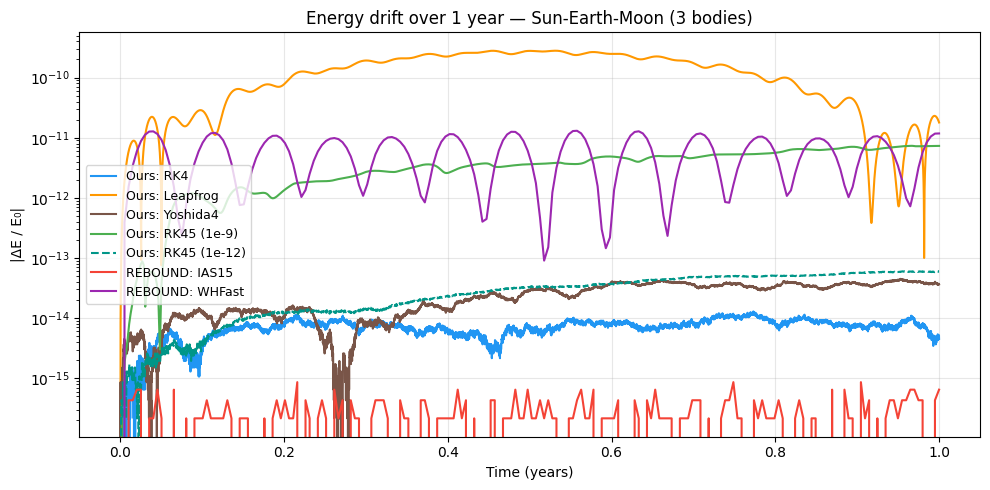

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

styles = {
    'Ours: RK4':          {'color': '#2196F3', 'ls': '-'},
    'Ours: Leapfrog':     {'color': '#FF9800', 'ls': '-'},
    'Ours: Yoshida4':     {'color': '#795548', 'ls': '-'},
    'Ours: RK45 (1e-9)':  {'color': '#4CAF50', 'ls': '-'},
    'Ours: RK45 (1e-12)': {'color': '#009688', 'ls': '--'},
    'REBOUND: IAS15':     {'color': '#F44336', 'ls': '-'},
    'REBOUND: WHFast':    {'color': '#9C27B0', 'ls': '-'},
}

for label, r in results.items():
    s = styles.get(label, {})
    ax.plot(r['t'], np.abs(r['E_rel']), label=label,
            color=s.get('color'), ls=s.get('ls', '-'), linewidth=1.5)

ax.set_yscale('log')
ax.set_xlabel('Time (years)')
ax.set_ylabel('|ΔE / E₀|')
ax.set_title('Energy drift over 1 year — Sun-Earth-Moon (3 bodies)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Discussion

**Key observations:**

- **REBOUND IAS15** achieves near machine-precision drift — it is the accuracy gold standard for this type of problem
- **Our RK45 (atol=1e-9)** is the fastest integrator in wall-clock time with a fraction of the steps, at the cost of moderate precision
- **Our Yoshida4** is our best fixed-step integrator: 4th-order symplectic, so it preserves a modified Hamiltonian exactly. It significantly outperforms Leapfrog at the same timestep and beats REBOUND WHFast despite being a much simpler algorithm. The cost is 3× more force evaluations per step than Leapfrog.
- **Our RK4** appears to have low drift on 1-year runs because non-symplectic errors cancel over the integration interval. Over multi-year runs, RK4 drift grows secularly while Yoshida4 stays bounded.
- **REBOUND WHFast** is also symplectic (Wisdom-Holman), but Yoshida4 at 4th order beats it on pure energy conservation at equal timestep.

**Integrator selection guide:**

| Use case | Recommended |
|---|---|
| Fast, moderate precision | RK45 (atol=1e-9) |
| High accuracy, short run | RK45 (atol=1e-12) or RK4 |
| Long-term (> 10 years) | Yoshida4 — bounded drift, no secular growth |
| Maximum accuracy | REBOUND IAS15 |
